In [ ]:
#pip install efficient_apriori

In [ ]:
import os

os.chdir(r"C:\Users\haley\OneDrive\Desktop\School\Fall '25\MIS 776")
print(os.getcwd())  # confirm directory

C:\Users\haley\OneDrive\Desktop\School\Fall '25\MIS 776


In [ ]:
#Import necessary libraries
import pandas as pd
import string
import warnings
warnings.filterwarnings("ignore")
import numpy as np
from efficient_apriori import apriori
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

In [ ]:
#read the csv file
data = pd.read_csv('onlineRetail2.csv')

#Create 'remove_time' function to remove the times from the InvoiceDate values
def remove_time(text):
    words = text.split()
    if len(words) > 1:
        return ' '.join(words[0:1] + words[2:])
    else:
        return text

#Apply the remove_time function to the InvoiceDate column
#Strip any leading or trailing spaces and punctuations from the Description values
data["InvoiceDate"] = data["InvoiceDate"].apply(remove_time)
data["Description"] = (data["Description"].str.strip().str.strip(string.punctuation))

#Remove rows with missing values
data = data.dropna()
# Remove rows with negative Quantity
print("\nRows with negative Quantity:", len(data.loc[data['Quantity'] < 0]))
data = data[data['Quantity'] > 0]

print("\nFirst Rows\n\n", data.head(3))


Rows with negative Quantity: 8905

First Rows

   Invoice StockCode                         Description  Quantity InvoiceDate  \
0  536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6     12/1/10   
1  536365     71053                 WHITE METAL LANTERN         6     12/1/10   
2  536365    84406B      CREAM CUPID HEARTS COAT HANGER         8     12/1/10   

   Price  Customer ID         Country  
0   2.55      17850.0  United Kingdom  
1   3.39      17850.0  United Kingdom  
2   2.75      17850.0  United Kingdom  


In [ ]:
#Group prices by country
country_prices = data.groupby('Country')['Price'].sum()
print(country_prices)

Country
Australia                  3612.500
Austria                    1693.900
Bahrain                      78.950
Belgium                    7372.850
Brazil                      142.600
Canada                      910.580
Channel Islands            3389.650
Cyprus                     3506.180
Czech Republic               78.270
Denmark                    1195.550
EIRE                      32179.280
European Community          289.800
Finland                    3628.440
France                    36850.040
Germany                   33532.140
Greece                      663.290
Iceland                     481.210
Israel                      904.440
Italy                      3576.210
Japan                       657.210
Lebanon                     242.440
Lithuania                    99.440
Malta                       545.190
Netherlands                6247.730
Norway                     5662.470
Poland                     1377.210
Portugal                   8663.040
RSA                 

In [ ]:
#Evaluate the statistics of the data
print("Rows and columns:", data.shape)
print("\nSummary Statistics\n\n", data[["Quantity", "Price"]].describe())

#Group item quantities with the description
item_quantity = data.groupby("Description")["Quantity"].sum().reset_index()
item_quantity = item_quantity.sort_values(by="Quantity", ascending=False).reset_index()

print("\nGreatest Quantity Items:\n", item_quantity[:10])
print("\nAverage Items Per Invoice:", data['Description'].str.len().mean())
print("\nInvoice Dates\n\n", data["InvoiceDate"].unique())

Rows and columns: (397925, 8)

Summary Statistics

             Quantity          Price
count  397925.000000  397925.000000
mean       13.021793       3.116212
std       180.419984      22.096773
min         1.000000       0.000000
25%         2.000000       1.250000
50%         6.000000       1.950000
75%        12.000000       3.750000
max     80995.000000    8142.750000

Greatest Quantity Items:
    index                         Description  Quantity
0   2310         PAPER CRAFT , LITTLE BIRDIE     80995
1   1981      MEDIUM CERAMIC TOP STORAGE JAR     77916
2   3775   WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
3   1751             JUMBO BAG RED RETROSPOT     46181
4   3687  WHITE HANGING HEART T-LIGHT HOLDER     36725
5    206       ASSORTED COLOUR BIRD ORNAMENT     35362
6   2260     PACK OF 72 RETROSPOT CAKE CASES     33693
7   2588                      POPCORN HOLDER     30931
8   2644                  RABBIT NIGHT LIGHT     27202
9   2036              MINI PAINT SET VINTAGE   

In [ ]:
#Create indices of repeated rows in accordance to its Quantity value, saved in a new DataFrame
#Remove the Quanity column (now that each item is repeated by quantity)
multiply_items = data.loc[data.index.repeat(data['Quantity'])]
multiply_items = multiply_items.drop('Quantity', axis=1)
print(multiply_items.head(50))
print("\nRows and columns expanding invoice items:", multiply_items.shape)

  Invoice StockCode                          Description InvoiceDate  Price  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER     12/1/10   2.55   
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER     12/1/10   2.55   
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER     12/1/10   2.55   
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER     12/1/10   2.55   
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER     12/1/10   2.55   
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER     12/1/10   2.55   
1  536365     71053                  WHITE METAL LANTERN     12/1/10   3.39   
1  536365     71053                  WHITE METAL LANTERN     12/1/10   3.39   
1  536365     71053                  WHITE METAL LANTERN     12/1/10   3.39   
1  536365     71053                  WHITE METAL LANTERN     12/1/10   3.39   
1  536365     71053                  WHITE METAL LANTERN     12/1/10   3.39   
1  536365     71053                  WHITE METAL LAN

In [ ]:
#Group the data by Invoice and its list of Description values
agg_data = multiply_items.groupby('Invoice')['Description'].agg(list).reset_index()
print(agg_data)

#Reorganize data as list of lists (required by apriori)
records = []
for i in range(0, len(agg_data)):
    records.append(agg_data.iloc[i,1])

      Invoice                                        Description
0      536365  [WHITE HANGING HEART T-LIGHT HOLDER, WHITE HAN...
1      536366  [HAND WARMER UNION JACK, HAND WARMER UNION JAC...
2      536367  [ASSORTED COLOUR BIRD ORNAMENT, ASSORTED COLOU...
3      536368  [JAM MAKING SET WITH JARS, JAM MAKING SET WITH...
4      536369  [BATH BUILDING BLOCK WORD, BATH BUILDING BLOCK...
...       ...                                                ...
18531  581583  [LUNCH BAG RED RETROSPOT, LUNCH BAG RED RETROS...
18532  581584  [RED FLOCK LOVE HEART PHOTO FRAME, RED FLOCK L...
18533  581585  [BLACK TEA TOWEL CLASSIC DESIGN, BLACK TEA TOW...
18534  581586  [LARGE CAKE STAND  HANGING STRAWBERY, LARGE CA...
18535  581587  [CIRCUS PARADE LUNCH BOX, CIRCUS PARADE LUNCH ...

[18536 rows x 2 columns]


In [ ]:
#Iterates through the items and lists them with their number
for i in range(len(records[0])):
    print(i + 1, " ", records[0][i])

1   WHITE HANGING HEART T-LIGHT HOLDER
2   WHITE HANGING HEART T-LIGHT HOLDER
3   WHITE HANGING HEART T-LIGHT HOLDER
4   WHITE HANGING HEART T-LIGHT HOLDER
5   WHITE HANGING HEART T-LIGHT HOLDER
6   WHITE HANGING HEART T-LIGHT HOLDER
7   WHITE METAL LANTERN
8   WHITE METAL LANTERN
9   WHITE METAL LANTERN
10   WHITE METAL LANTERN
11   WHITE METAL LANTERN
12   WHITE METAL LANTERN
13   CREAM CUPID HEARTS COAT HANGER
14   CREAM CUPID HEARTS COAT HANGER
15   CREAM CUPID HEARTS COAT HANGER
16   CREAM CUPID HEARTS COAT HANGER
17   CREAM CUPID HEARTS COAT HANGER
18   CREAM CUPID HEARTS COAT HANGER
19   CREAM CUPID HEARTS COAT HANGER
20   CREAM CUPID HEARTS COAT HANGER
21   KNITTED UNION FLAG HOT WATER BOTTLE
22   KNITTED UNION FLAG HOT WATER BOTTLE
23   KNITTED UNION FLAG HOT WATER BOTTLE
24   KNITTED UNION FLAG HOT WATER BOTTLE
25   KNITTED UNION FLAG HOT WATER BOTTLE
26   KNITTED UNION FLAG HOT WATER BOTTLE
27   RED WOOLLY HOTTIE WHITE HEART
28   RED WOOLLY HOTTIE WHITE HEART
29   RED WOOLLY

In [ ]:
itemsets, rules = apriori(records, min_support=0.01)
print("Total association rules generated:", len(rules), "\n")
# Print out every rule with 2 items on the left hand side,
# 1 item on the right hand side, sorted by lift
rules_rhs = filter(lambda rule: len(rule.lhs) == 2 and len(rule.rhs) == 1, rules)
rules_print = 0
for rule in sorted(rules_rhs, key=lambda rule: rule.lift, reverse=True):
    if rules_print > 20:
        break
    print(rule)
    rules_print += 1

Total association rules generated: 275 

{POPPY'S PLAYHOUSE BEDROOM, POPPY'S PLAYHOUSE KITCHEN} -> {POPPY'S PLAYHOUSE LIVINGROOM} (conf: 0.732, supp: 0.010, lift: 53.864, conv: 3.685)
{POPPY'S PLAYHOUSE KITCHEN, POPPY'S PLAYHOUSE LIVINGROOM} -> {POPPY'S PLAYHOUSE BEDROOM} (conf: 0.865, supp: 0.010, lift: 50.746, conv: 7.287)
{POPPY'S PLAYHOUSE BEDROOM, POPPY'S PLAYHOUSE LIVINGROOM} -> {POPPY'S PLAYHOUSE KITCHEN} (conf: 0.907, supp: 0.010, lift: 48.607, conv: 10.588)
{GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER} -> {PINK REGENCY TEACUP AND SAUCER} (conf: 0.725, supp: 0.015, lift: 24.157, conv: 3.522)
{GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER} -> {PINK REGENCY TEACUP AND SAUCER} (conf: 0.721, supp: 0.021, lift: 24.033, conv: 3.475)
{PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER} -> {GREEN REGENCY TEACUP AND SAUCER} (conf: 0.894, supp: 0.021, lift: 23.995, conv: 9.125)
{PINK REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER} -> {GR

In [ ]:
#Price and quantity of two items
a = data[data['Description'] == 'REGENCY TEA PLATE PINK']
b = data[data['Description'] == 'REGENCY TEA PLATE GREEN']

#-----PINK PLATE-----
#Group each product by date and compute the mean
#aq = Total quantity sold each day
#ap = Average price that day
aq = a.groupby("InvoiceDate")["Quantity"].sum().reset_index()
ap = a.groupby("InvoiceDate")["Price"].mean().reset_index()
aq = aq.rename(columns={'Quantity': 'a_Quantity'})
ap = ap.rename(columns={'Price': 'a_Price'})
print(aq)

#-----GREEN PLATE-----
#Repeat same steps for pink plate
bq = b.groupby("InvoiceDate")["Quantity"].sum().reset_index()
bp = b.groupby("InvoiceDate")["Price"].sum().reset_index()
bq = bq.rename(columns={'Quantity': 'b_Quantity'})
bp = bp.rename(columns={'Price': 'b_Price'})

#Merge the components of each item
m = pd.merge(ap, aq, on='InvoiceDate', how='inner')
m = pd.merge(m, bp, on='InvoiceDate', how='inner')
m = pd.merge(m, bq, on='InvoiceDate', how='inner')
print(m)

    InvoiceDate  a_Quantity
0      10/10/11          13
1      10/11/11          12
2      10/12/11          12
3      10/13/11          24
4      10/16/11          12
..          ...         ...
114     9/30/11          24
115      9/4/11          12
116      9/6/11          84
117      9/7/11          24
118      9/8/11           2

[119 rows x 2 columns]
    InvoiceDate   a_Price  a_Quantity  b_Price  b_Quantity
0      10/10/11  1.650000          13     6.59          15
1      10/11/11  1.650000          12     1.65          12
2      10/12/11  1.650000          12     1.65          12
3      10/13/11  1.650000          24     3.30          24
4      10/16/11  1.650000          12     1.65           6
..          ...       ...         ...      ...         ...
110     9/30/11  1.650000          24     1.65          24
111      9/4/11  1.650000          12     1.65          12
112      9/6/11  1.583333          84     4.75          78
113      9/7/11  1.650000          24     3.30    

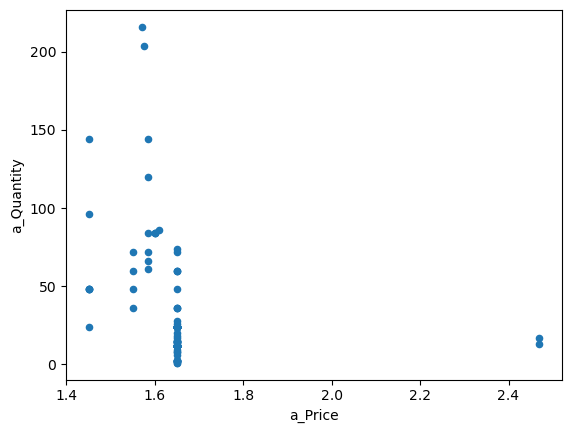

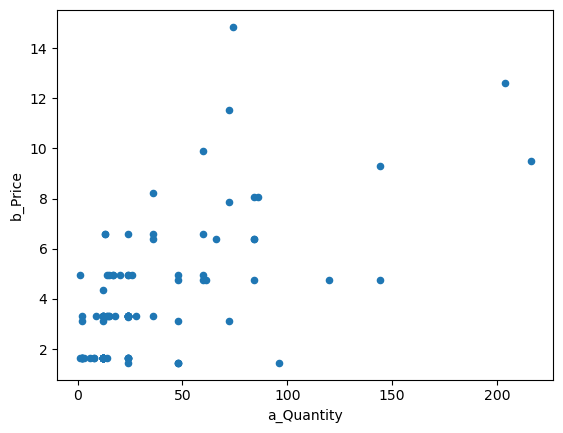

In [ ]:
#Create scatterplot to reflect average price of pink plate for each date to the quantity sold
m.plot.scatter(x='a_Price', y='a_Quantity')
plt.show()
#Create scatterplot to reflect quanity of pink plates sold to the total summed priced of green plates
m.plot.scatter(x='a_Quantity', y='b_Price')
plt.show()

## Using Quantity for Association Rules

In [ ]:
num_bins = 5
data2 = data

#Use Quantity distribution for max bin
bins = np.linspace(0, 20, num_bins + 1)
print("Bins: ", bins)

#Label each row with its bin and create an item label
data2['Bin'] = pd.cut(data2['Quantity'], bins=bins, labels=[f'Bin {i+1}' for i in range(num_bins)])
data2['Item'] = data2['Description'].astype(str) + '_' + data2['Bin'].astype(str)

#Count
print("\n\n", data2.iloc[1000:1005])
bin_count = data2.groupby('Bin').count()
print(data2["Bin"].value_counts())

#Groups each invoice and compiles its Item into a list
agg_data2 = data2.groupby('Invoice')['Item'].agg(list).reset_index()
# Reorganize data as list of lists (required by apriori)
records2 = []
for i in range(0, len(agg_data2)):
    records2.append(agg_data2.iloc[i,1])

Bins:  [ 0.  4.  8. 12. 16. 20.]


      Invoice StockCode                         Description  Quantity  \
1011  536520    84985A       SET OF 72 GREEN PAPER DOILIES         1   
1012  536520     20754     RETROSPOT RED WASHING UP GLOVES         1   
1013  536520    84596E        SMALL LICORICE DES PINK BOWL         1   
1014  536520     21111  SWISS ROLL TOWEL, CHOCOLATE  SPOTS         1   
1015  536520     22501          PICNIC BASKET WICKER LARGE         1   

     InvoiceDate  Price  Customer ID         Country    Bin  \
1011     12/1/10   1.45      14729.0  United Kingdom  Bin 1   
1012     12/1/10   2.10      14729.0  United Kingdom  Bin 1   
1013     12/1/10   1.25      14729.0  United Kingdom  Bin 1   
1014     12/1/10   2.95      14729.0  United Kingdom  Bin 1   
1015     12/1/10   9.95      14729.0  United Kingdom  Bin 1   

                                          Item  
1011       SET OF 72 GREEN PAPER DOILIES_Bin 1  
1012     RETROSPOT RED WASHING UP GLOVES_Bin 1  
1013 

In [ ]:
#Show total association rules
itemsets, rules = apriori(records2, min_support=0.01)
print("Total association rules generated:", len(rules), "\n")

#Keep rules with 1:1 ratio
rules_rhs = filter(lambda rule: len(rule.lhs) == 1 and len(rule.rhs) == 1, rules)
rules_print = 0

#Sort
for rule in sorted(rules_rhs, key=lambda rule: rule.lift, reverse=True):
    if rules_print >= 20:
        break
    print(rule)
    rules_print += 1

Total association rules generated: 18 

{PINK HAPPY BIRTHDAY BUNTING_Bin 1} -> {BLUE HAPPY BIRTHDAY BUNTING_Bin 1} (conf: 0.702, supp: 0.010, lift: 47.482, conv: 3.305)
{BLUE HAPPY BIRTHDAY BUNTING_Bin 1} -> {PINK HAPPY BIRTHDAY BUNTING_Bin 1} (conf: 0.679, supp: 0.010, lift: 47.482, conv: 3.069)
{PINK REGENCY TEACUP AND SAUCER_Bin 2} -> {GREEN REGENCY TEACUP AND SAUCER_Bin 2} (conf: 0.812, supp: 0.013, lift: 41.116, conv: 5.210)
{GREEN REGENCY TEACUP AND SAUCER_Bin 2} -> {PINK REGENCY TEACUP AND SAUCER_Bin 2} (conf: 0.637, supp: 0.013, lift: 41.116, conv: 2.709)
{ROSES REGENCY TEACUP AND SAUCER_Bin 2} -> {PINK REGENCY TEACUP AND SAUCER_Bin 2} (conf: 0.522, supp: 0.011, lift: 33.711, conv: 2.060)
{PINK REGENCY TEACUP AND SAUCER_Bin 2} -> {ROSES REGENCY TEACUP AND SAUCER_Bin 2} (conf: 0.704, supp: 0.011, lift: 33.711, conv: 3.306)
{GARDENERS KNEELING PAD KEEP CALM_Bin 1} -> {GARDENERS KNEELING PAD CUP OF TEA_Bin 1} (conf: 0.647, supp: 0.012, lift: 33.596, conv: 2.779)
{GARDENERS KNEELIN

## Cluster Items

In [ ]:
#Apply TF-IDF vectorizer to Description items
#Output will be a numeric vector of the descriptions that were vectorized
items = data["Description"]
vectorizer = TfidfVectorizer()
vec_items = vectorizer.fit_transform(items)

In [ ]:
#Specify 5 clusters and apply the k-means clustering model
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(vec_items)
results = pd.DataFrame()
results['document'] = items
results['cluster'] = kmeans.labels_

In [ ]:
#Iterate through each k cluster and sample 50% of the rows
for k in range(0, 5):
    print(results[results["cluster"] == k].sample(frac=0.5))

                                  document  cluster
445963  SET OF 3 WOODEN SLEIGH DECORATIONS        0
228627              JAM MAKING SET PRINTED        0
306094    SET OF 3 HANGING OWLS OLLIE BEAK        0
226042    SET OF 3 CAKE TINS PANTRY DESIGN        0
488384       SET OF 3 HEART COOKIE CUTTERS        0
...                                    ...      ...
118504      PACK OF 6 PANNETONE GIFT BOXES        0
342970          SET OF 10 LED DOLLY LIGHTS        0
194494     SET OF 16 VINTAGE BLACK CUTLERY        0
468240            JAM MAKING SET WITH JARS        0
266919     SET/20 STRAWBERRY PAPER NAPKINS        0

[26910 rows x 2 columns]
                                  document  cluster
412415                RED STAR CARD HOLDER        1
109017  WHITE HANGING HEART T-LIGHT HOLDER        1
220694        ANTIQUE SILVER T-LIGHT GLASS        1
9982      HANGING HEART JAR T-LIGHT HOLDER        1
156058         T-LIGHT HOLDER HANGING LACE        1
...                                   